## 1. Setup & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import os
import glob
import warnings

warnings.filterwarnings('ignore')

# Plot Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED', '#0891B2']

# Paths
RAW_PATH = '../data/raw/on_time/'
LOOKUP_PATH = '../data/raw/lookup/'
OUTPUT_PATH = '../assets/images/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"   RAW_PATH  : {os.path.abspath(RAW_PATH)}")
print(f"   LOOKUP    : {os.path.abspath(LOOKUP_PATH)}")

   RAW_PATH  : d:\App\us-aviation-analytics\data\raw\on_time
   LOOKUP    : d:\App\us-aviation-analytics\data\raw\lookup


## 2. Load Sample Data

In [4]:
DTYPE_MAP = {
    'YEAR': 'int16',
    'QUARTER': 'int8',
    'MONTH': 'int8',
    'DAY_OF_MONTH': 'int8',
    'DAY_OF_WEEK': 'int8',

    'OP_UNIQUE_CARRIER': 'str',
    'OP_CARRIER': 'str',
    'TAIL_NUM': 'str',

    'ORIGIN': 'str',
    'ORIGIN_CITY_NAME': 'str',
    'ORIGIN_STATE_ABR': 'str',

    'DEST': 'str',
    'DEST_CITY_NAME': 'str',
    'DEST_STATE_ABR': 'str',

    'CANCELLATION_CODE': 'str',
}


def load_month(year: int, month: int) -> pd.DataFrame:
    """Load one month of BTS on-time data."""

    pattern = os.path.join(
        RAW_PATH,
        f'ontime_{year}_{month:02d}.csv'
    )

    files = glob.glob(pattern)

    if not files:
        raise FileNotFoundError(
            f"File not found: {pattern}"
        )

    df = pd.read_csv(
        files[0],
        dtype=DTYPE_MAP,
        low_memory=False,
        parse_dates=['FL_DATE']
    )

    # Drop unnamed columns if they exist
    df = df.loc[
        :,
        ~df.columns.str.startswith('Unnamed')
    ]

    return df


# Load sample
df_sample = load_month(2019, 1)

print(
    f"Shape         : "
    f"{df_sample.shape[0]:,} rows × "
    f"{df_sample.shape[1]} columns"
)

print(
    f"Memory Usage  : "
    f"{df_sample.memory_usage(deep=True).sum() / 1e6:.1f} MB"
)

print(
    f"Date Range    : "
    f"{df_sample['FL_DATE'].min()} → "
    f"{df_sample['FL_DATE'].max()}"
)

Shape         : 583,985 rows × 48 columns
Memory Usage  : 461.2 MB
Date Range    : 2019-01-01 00:00:00 → 2019-01-31 00:00:00


## 3. Schema Inspection

In [5]:
print("=" * 70)
print("SCHEMA OVERVIEW")
print("=" * 70)

schema_info = pd.DataFrame({
    'Column': df_sample.columns,
    'Dtype': df_sample.dtypes.values,
    'Non-Null Count': df_sample.notna().sum().values,
    'Null Count': df_sample.isna().sum().values,
    'Null %': (df_sample.isna().sum() / len(df_sample) * 100).round(2).values,
    'Sample Value': [str(df_sample[col].dropna().iloc[0]) 
                     if df_sample[col].notna().any() else 'ALL NULL' 
                     for col in df_sample.columns]
})

print(schema_info.to_string(index=False))

print(f"\nTotal Columns : {len(df_sample.columns)}")
print(f"Total Rows    : {len(df_sample):,}")

SCHEMA OVERVIEW
             Column          Dtype  Non-Null Count  Null Count  Null %        Sample Value
               YEAR          int16          583985           0    0.00                2019
            QUARTER           int8          583985           0    0.00                   1
              MONTH           int8          583985           0    0.00                   1
       DAY_OF_MONTH           int8          583985           0    0.00                   1
        DAY_OF_WEEK           int8          583985           0    0.00                   2
            FL_DATE datetime64[us]          583985           0    0.00 2019-01-01 00:00:00
  OP_UNIQUE_CARRIER            str          583985           0    0.00                  9E
         OP_CARRIER            str          583985           0    0.00                  9E
           TAIL_NUM            str          581442        2543    0.44              N131EV
  OP_CARRIER_FL_NUM          int64          583985           0    0.00    

## 4. Missing Value

In [ ]:
DELAY_CAUSE_COLS = [
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

KEY_COLS = [
    'FL_DATE',
    'OP_UNIQUE_CARRIER',
    'OP_CARRIER_FL_NUM',
    'ORIGIN',
    'DEST',
    'ARR_DELAY',
    'ARR_DEL15',
    'CANCELLED',
    'DEP_DELAY',
    'TAXI_OUT',
    'TAXI_IN',
    'AIR_TIME'
] + DELAY_CAUSE_COLS

missing_df = pd.DataFrame({
    'Column': KEY_COLS,
    'Null Count': [df_sample[c].isna().sum() for c in KEY_COLS],
    'Null %': [(df_sample[c].isna().sum() / len(df_sample) * 100).round(2) for c in KEY_COLS],
}).sort_values('Null %', ascending=False)

print("=" * 60)
print("MISSING VALUE SUMMARY — KEY COLUMNS")
print("=" * 60)
print(missing_df.to_string(index=False))

# Verify: Are delay cause NULLs explained by ARR_DEL15 = 0?
cancelled_count = (df_sample['CANCELLED'] == 1).sum()
ontime_count = (df_sample['ARR_DEL15'] == 0).sum()
delayed_count = (df_sample['ARR_DEL15'] == 1).sum()

print(f"\n{'─'*60}")
print("FLIGHT STATUS BREAKDOWN")
print(f"{'─'*60}")
print(f"Cancelled                  : {cancelled_count:,} ({cancelled_count/len(df_sample)*100:.1f}%)")
print(f"On-Time (ARR_DEL15 = 0)    : {ontime_count:,} ({ontime_count/len(df_sample)*100:.1f}%)")
print(f"Delayed (ARR_DEL15 = 1)    : {delayed_count:,} ({delayed_count/len(df_sample)*100:.1f}%)")

# Verify: Do delayed flights have delay cause data?
delayed_flights = df_sample[df_sample['ARR_DEL15'] == 1]
print(f"\n{'─'*60}")
print("DELAY CAUSE COVERAGE (Among Delayed Flights Only)")
print(f"{'─'*60}")
for col in DELAY_CAUSE_COLS:
    null_pct = delayed_flights[col].isna().sum() / len(delayed_flights) * 100
    print(f"  {col:<22}: {null_pct:.1f}% NULL among delayed flights")

print("\nNote: Delay cause NULLs in non-delayed/cancelled flights are EXPECTED (MAR).")
print("   Delay cause NULLs in DELAYED flights would indicate a data quality issue.")

MISSING VALUE SUMMARY — KEY COLUMNS
             Column  Null Count  Null %
      WEATHER_DELAY      478763   81.98
      CARRIER_DELAY      478763   81.98
          NAS_DELAY      478763   81.98
     SECURITY_DELAY      478763   81.98
LATE_AIRCRAFT_DELAY      478763   81.98
           AIR_TIME       18022    3.09
          ARR_DEL15       18022    3.09
          ARR_DELAY       18022    3.09
            TAXI_IN       17061    2.92
           TAXI_OUT       16616    2.85
          DEP_DELAY       16355    2.80
            FL_DATE           0    0.00
          CANCELLED           0    0.00
  OP_UNIQUE_CARRIER           0    0.00
  OP_CARRIER_FL_NUM           0    0.00
             ORIGIN           0    0.00
               DEST           0    0.00

────────────────────────────────────────────────────────────
FLIGHT STATUS BREAKDOWN
────────────────────────────────────────────────────────────
Cancelled                  : 16,726 (2.9%)
On-Time (ARR_DEL15 = 0)    : 460,741 (78.9%)
Delayed (

## 5. Full Period Volume

In [ ]:
SUMMARY_COLS = [
    'YEAR', 'MONTH', 'OP_UNIQUE_CARRIER',
    'FLIGHTS', 'CANCELLED', 'ARR_DEL15', 'ARR_DELAY',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

all_months = []

print("Loading all 60 months...")
for year in range(2019, 2024):
    for month in range(1, 13):
        pattern = os.path.join(RAW_PATH, f'ontime_{year}_{month:02d}.csv')
        files = glob.glob(pattern)
        if files:
            chunk = pd.read_csv(
                files[0],
                usecols=SUMMARY_COLS,
                dtype={'OP_UNIQUE_CARRIER': 'str'},
                low_memory=False
            )
            all_months.append(chunk)
            print(f"  ✓ {year}-{month:02d}: {len(chunk):,} rows", end='\r')

df_all = pd.concat(all_months, ignore_index=True)
print(f"\n\nTotal Records Loaded: {len(df_all):,}")
print(f"   Memory Usage         : {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading all 60 months...
  ✓ 2023-12: 570,394 rows

Total Records Loaded: 31,579,597
   Memory Usage         : 4389.6 MB


## 6. Temporal Coverage & Covid Impact

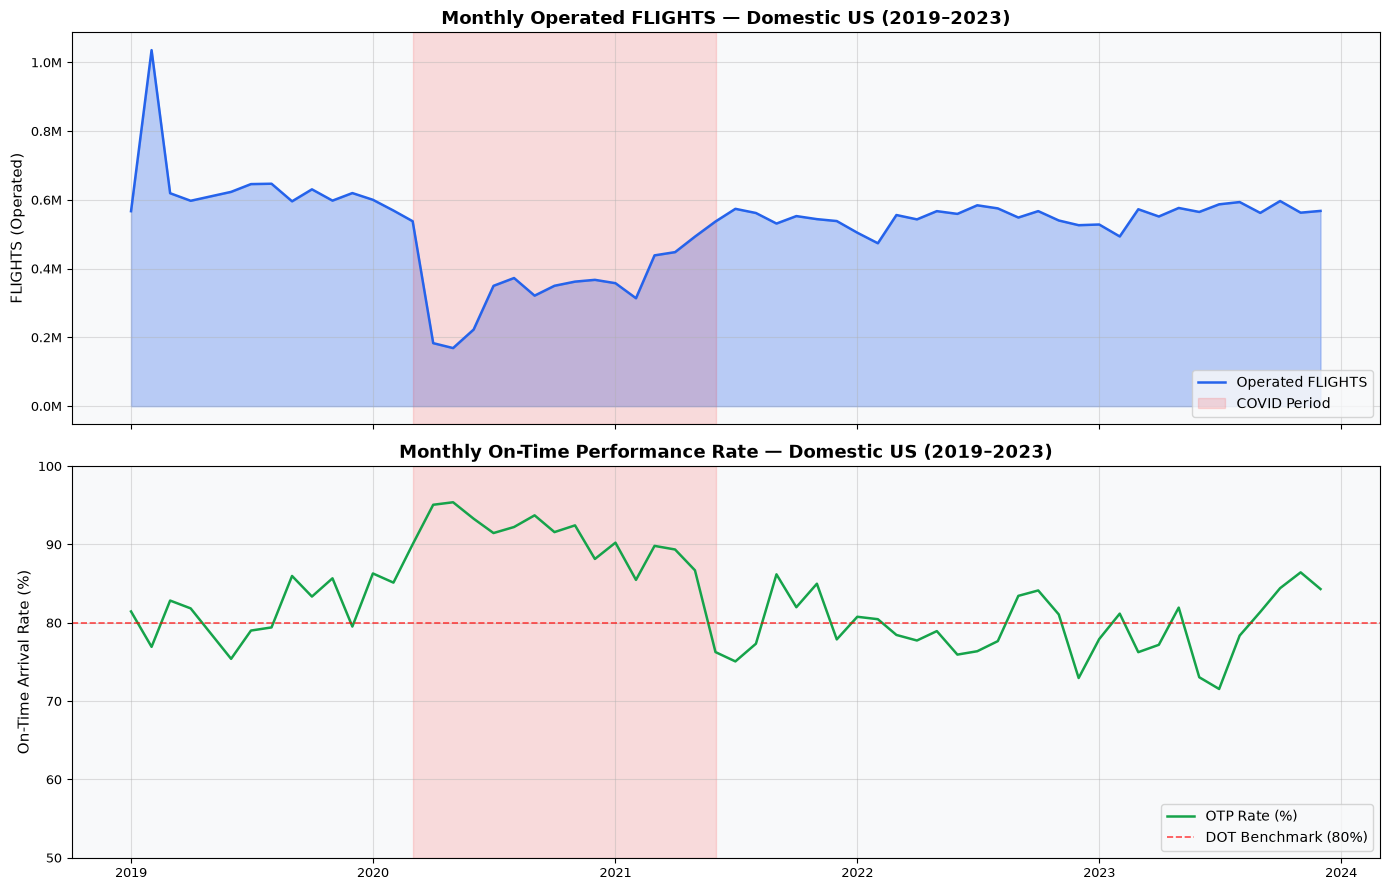

Key Observations:
  Avg Monthly FLIGHTS 2019     : 652,878
  Avg Monthly FLIGHTS Apr-May 2020: 176,154 (-73% vs 2019)
  Avg Monthly FLIGHTS 2023     : 563,330 (-14% vs 2019)


In [ ]:
monthly = (
    df_all
    .groupby(['YEAR', 'MONTH'])
    .agg(
        total_flights=('FLIGHTS', 'sum'),
        cancelled=('CANCELLED', 'sum'),
        delayed=('ARR_DEL15', 'sum')
    )
    .reset_index()
)

monthly['period'] = pd.to_datetime(
    monthly['YEAR'].astype(str) + '-' + monthly['MONTH'].astype(str) + '-01'
)
monthly['operated'] = monthly['total_flights'] - monthly['cancelled']
monthly['otp_rate'] = (
    (monthly['operated'] - monthly['delayed']) / monthly['operated'] * 100
).round(2)
monthly['cancel_rate'] = (
    monthly['cancelled'] / monthly['total_flights'] * 100
).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Plot 1: Flight Volume
ax1 = axes[0]
ax1.fill_between(monthly['period'], monthly['operated'],
                 alpha=0.3, color=PALETTE[0])
ax1.plot(monthly['period'], monthly['operated'],
         color=PALETTE[0], linewidth=1.8, label='Operated FLIGHTS')
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
            alpha=0.12, color='red', label='COVID Period')
ax1.set_ylabel('FLIGHTS (Operated)')
ax1.set_title('Monthly Operated FLIGHTS — Domestic US (2019–2023)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.legend(loc='lower right')

# Plot 2: On-Time Performance Rate
ax2 = axes[1]
ax2.plot(monthly['period'], monthly['otp_rate'],
         color=PALETTE[2], linewidth=1.8, label='OTP Rate (%)')
ax2.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
            label='DOT Benchmark (80%)')
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
            alpha=0.12, color='red')
ax2.set_ylabel('On-Time Arrival Rate (%)')
ax2.set_title('Monthly On-Time Performance Rate — Domestic US (2019–2023)', fontweight='bold')
ax2.set_ylim(50, 100)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '00_monthly_volume_otp.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Key Observations:")
pre_covid = monthly[monthly['YEAR'] == 2019]['operated'].mean()
covid_low = monthly[(monthly['YEAR'] == 2020) & 
                    (monthly['MONTH'].isin([4, 5]))]['operated'].mean()
recovery = monthly[monthly['YEAR'] == 2023]['operated'].mean()
print(f"  Avg Monthly FLIGHTS 2019     : {pre_covid:,.0f}")
print(f"  Avg Monthly FLIGHTS Apr-May 2020: {covid_low:,.0f} "
      f"({(covid_low/pre_covid-1)*100:.0f}% vs 2019)")
print(f"  Avg Monthly FLIGHTS 2023     : {recovery:,.0f} "
      f"({(recovery/pre_covid-1)*100:.0f}% vs 2019)")

## 7. Arrival Delay Distribution

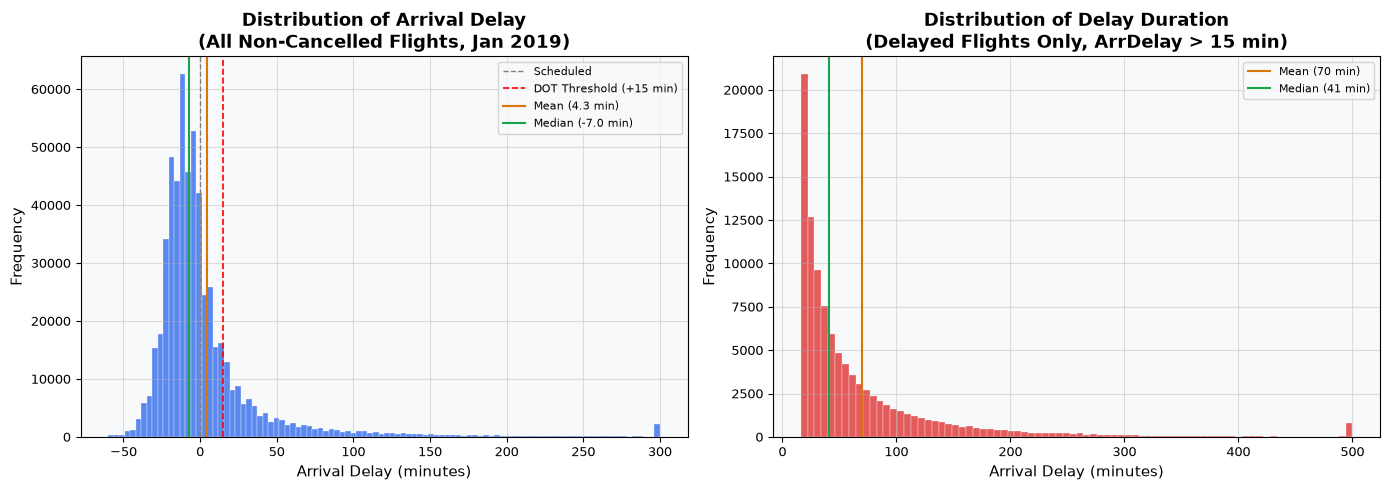

Descriptive Statistics — Arrival Delay (All Non-Cancelled):
count    565963.00
mean          4.26
std          51.16
min         -85.00
25%         -16.00
50%          -7.00
75%           7.00
max        1638.00
Name: ARR_DELAY, dtype: str

  Skewness : 8.8379  (positive = right-skewed)
  Kurtosis : 142.5384  (high = heavy tail)


In [23]:
arr_delay_data = df_sample.loc[
    (df_sample['CANCELLED'] == 0) & 
    (df_sample['ARR_DELAY'].notna()),
    'ARR_DELAY'
]

delayed_only = arr_delay_data[arr_delay_data > 15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full Distribution
ax = axes[0]
ax.hist(arr_delay_data.clip(-60, 300), bins=100,
        color=PALETTE[0], alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='Scheduled')
ax.axvline(15, color='red', linestyle='--', linewidth=1.2, label='DOT Threshold (+15 min)')
ax.axvline(arr_delay_data.mean(), color=PALETTE[3], linestyle='-',
           linewidth=1.5, label=f'Mean ({arr_delay_data.mean():.1f} min)')
ax.axvline(arr_delay_data.median(), color=PALETTE[2], linestyle='-',
           linewidth=1.5, label=f'Median ({arr_delay_data.median():.1f} min)')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Arrival Delay\n(All Non-Cancelled Flights, Jan 2019)', fontweight='bold')
ax.legend(fontsize=8)

# Delayed Flights Only 
ax2 = axes[1]
ax2.hist(delayed_only.clip(15, 500), bins=80,
         color=PALETTE[1], alpha=0.75, edgecolor='white', linewidth=0.3)
ax2.axvline(delayed_only.mean(), color=PALETTE[3], linestyle='-',
            linewidth=1.5, label=f'Mean ({delayed_only.mean():.0f} min)')
ax2.axvline(delayed_only.median(), color=PALETTE[2], linestyle='-',
            linewidth=1.5, label=f'Median ({delayed_only.median():.0f} min)')
ax2.set_xlabel('Arrival Delay (minutes)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Delay Duration\n(Delayed Flights Only, ArrDelay > 15 min)', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '00_arrival_delay_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Descriptive Statistics — Arrival Delay (All Non-Cancelled):")
print(arr_delay_data.describe().apply(lambda x: f"{x:.2f}"))
print(f"\n  Skewness : {arr_delay_data.skew():.4f}  (positive = right-skewed)")
print(f"  Kurtosis : {arr_delay_data.kurtosis():.4f}  (high = heavy tail)")

## 8. Delay Cause Composition

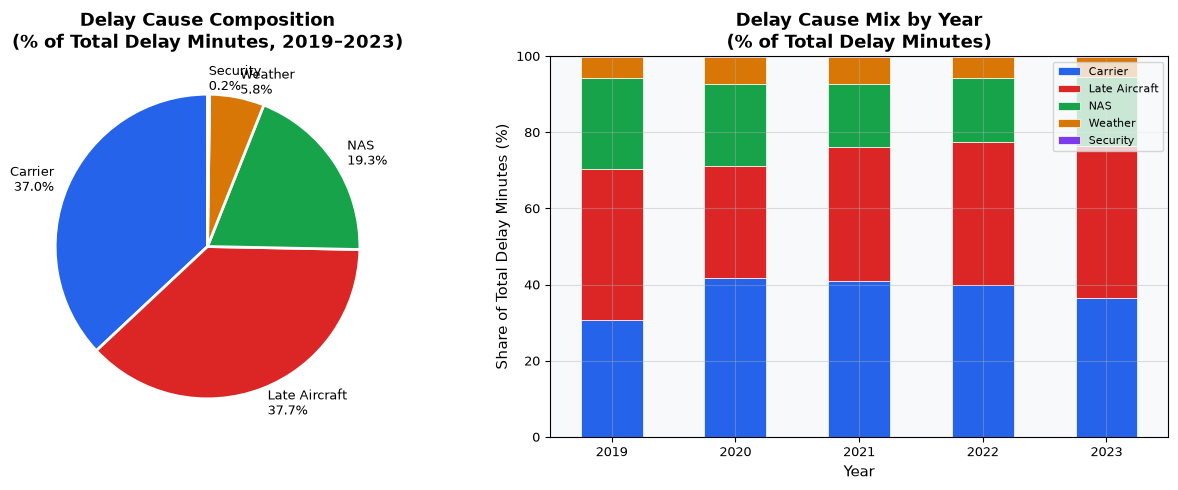


 Delay Cause Totals (2019–2023):
  Late Aircraft       : 0.14B minutes (37.7%)
  Carrier             : 0.14B minutes (37.0%)
  NAS                 : 0.07B minutes (19.3%)
  Weather             : 0.02B minutes (5.8%)
  Security            : 0.00B minutes (0.2%)


In [ ]:
# Filter to delayed flights with full delay cause data
delayed_full = df_all[
    (df_all['ARR_DEL15'] == 1) &
    (df_all['CARRIER_DELAY'].notna())
].copy()

cause_totals = {
    'Carrier': delayed_full['CARRIER_DELAY'].sum(),
    'Late Aircraft': delayed_full['LATE_AIRCRAFT_DELAY'].sum(),
    'NAS': delayed_full['NAS_DELAY'].sum(),
    'Weather': delayed_full['WEATHER_DELAY'].sum(),
    'Security': delayed_full['SECURITY_DELAY'].sum(),
}

total_delay_minutes = sum(cause_totals.values())
cause_pct = {k: v / total_delay_minutes * 100 for k, v in cause_totals.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie Chart
ax = axes[0]
sizes = list(cause_pct.values())
labels = [f"{k}\n{v:.1f}%" for k, v in cause_pct.items()]
wedges, texts = ax.pie(
    sizes, labels=labels, colors=PALETTE[:5],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Delay Cause Composition\n(% of Total Delay Minutes, 2019–2023)', fontweight='bold')

# Bar by Year
cause_cols = {
    'Carrier': 'CARRIER_DELAY',
    'Late Aircraft': 'LATE_AIRCRAFT_DELAY',
    'NAS': 'NAS_DELAY',
    'Weather': 'WEATHER_DELAY',
    'Security': 'SECURITY_DELAY'
}

yearly_cause = df_all[df_all['ARR_DEL15'] == 1].groupby('YEAR')[
    list(cause_cols.values())
].sum()

yearly_cause.columns = list(cause_cols.keys())
yearly_cause_pct = yearly_cause.div(yearly_cause.sum(axis=1), axis=0) * 100

ax2 = axes[1]
yearly_cause_pct.plot(
    kind='bar', stacked=True, ax=ax2,
    color=PALETTE[:5], edgecolor='white', linewidth=0.5
)
ax2.set_title('Delay Cause Mix by Year\n(% of Total Delay Minutes)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Total Delay Minutes (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.8)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '00_delay_cause_composition.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Delay Cause Totals (2019–2023):")
for cause, minutes in sorted(cause_totals.items(), key=lambda x: -x[1]):
    print(f"  {cause:<20}: {minutes/1e9:.2f}B minutes ({cause_pct[cause]:.1f}%)")

## 9. Data Quality

In [ ]:
print("=" * 65)
print("DATA QUALITY ASSESSMENT BASELINE — Jan 2019 Sample")
print("=" * 65)

dq_checks = []

def check(name, dimension, result, passed, note=""):
    status = "PASS" if passed else "FAIL"
    dq_checks.append({
        'Check': name, 
        'Dimension': dimension,
        'Result': result, 
        'Status': status,
        'Note': note
    })
    print(f"  {status}  [{dimension:<15}] {name}")
    print(f"           Result: {result}")
    if note:
        print(f"           Note  : {note}")
    print()

# Completeness
missing_key = df_sample['FL_DATE'].isna().sum()
check("FL_DATE has no nulls", "Completeness",
      f"{missing_key} nulls", missing_key == 0)

missing_carrier = df_sample['OP_UNIQUE_CARRIER'].isna().sum()
check("OP_UNIQUE_CARRIER has no nulls", "Completeness",
      f"{missing_carrier} nulls", missing_carrier == 0)

missing_origin = df_sample['ORIGIN'].isna().sum()
check("origin airport has no nulls", "Completeness",
      f"{missing_origin} nulls", missing_origin == 0)

# Validity
invalid_month = df_sample[(df_sample['MONTH'] < 1) | (df_sample['MONTH'] > 12)].shape[0]
check("Month values in valid range (1–12)", "Validity",
      f"{invalid_month} invalid records", invalid_month == 0)

invalid_dow = df_sample[(df_sample['DAY_OF_WEEK'] < 1) | (df_sample['DAY_OF_WEEK'] > 7)].shape[0]
check("DAY_OF_WEEK values in valid range (1–7)", "Validity",
      f"{invalid_dow} invalid records", invalid_dow == 0)

invalid_cancelled = df_sample[~df_sample['CANCELLED'].isin([0, 1])].shape[0]
check("CANCELLED flag is binary (0 or 1)", "Validity",
      f"{invalid_cancelled} invalid records", invalid_cancelled == 0)

invalid_arrdel15 = df_sample[
    df_sample['ARR_DEL15'].notna() & 
    ~df_sample['ARR_DEL15'].isin([0, 1])
].shape[0]
check("ARR_DEL15 flag is binary (0 or 1) where not null", "Validity",
      f"{invalid_arrdel15} invalid records", invalid_arrdel15 == 0)

# Consistency
# Check: For delayed flights (ARR_DEL15=1), delay cause should sum ≈ ArrDelayMinutes
delayed_check = df_sample[
    (df_sample['ARR_DEL15'] == 1) & 
    df_sample['CARRIER_DELAY'].notna()
].copy()

delayed_check['cause_sum'] = (
    delayed_check['CARRIER_DELAY'] + 
    delayed_check['WEATHER_DELAY'] +
    delayed_check['NAS_DELAY'] + 
    delayed_check['SECURITY_DELAY'] + 
    delayed_check['LATE_AIRCRAFT_DELAY']
)
delayed_check['diff'] = abs(
    delayed_check['cause_sum'] - delayed_check['ARR_DELAY_NEW']
)
inconsistent = (delayed_check['diff'] > 5).sum()
check(
    "Delay cause sum ≈ ARR_DELAY_NEW (±5 min tolerance)",
    "Consistency",
    f"{inconsistent} records with diff > 5 min "
    f"({inconsistent/len(delayed_check)*100:.1f}% of delayed flights)",
    inconsistent / len(delayed_check) < 0.05,
    note="Minor differences due to BTS rounding — expected."
)

# Uniqueness
natural_key_cols = [
    'FL_DATE', 'OP_UNIQUE_CARRIER',
    'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST'
]
dup_count = df_sample.duplicated(subset=natural_key_cols).sum()
check("Natural key has no duplicates", "Uniqueness",
      f"{dup_count} duplicates found",
      dup_count == 0,
      note="If > 0, investigate diverted flights or BTS data entry issues."
)

# Timeliness
date_range = df_sample['FL_DATE'].agg(['min', 'max'])
check(
    "Date range matches expected period",
    "Timeliness",
    f"{date_range['min']} → {date_range['max']}",
    True
)

# Summary
dq_df = pd.DataFrame(dq_checks)
pass_count = (dq_df['Status'] == 'PASS').sum()
fail_count = (dq_df['Status'] == 'FAIL').sum()

print("=" * 65)
print(f"SUMMARY: {pass_count} PASSED | {fail_count} FAILED")
print("=" * 65)

DATA QUALITY ASSESSMENT BASELINE — Jan 2019 Sample
  PASS  [Completeness   ] FL_DATE has no nulls
           Result: 0 nulls

  PASS  [Completeness   ] OP_UNIQUE_CARRIER has no nulls
           Result: 0 nulls

  PASS  [Completeness   ] origin airport has no nulls
           Result: 0 nulls

  PASS  [Validity       ] Month values in valid range (1–12)
           Result: 0 invalid records

  PASS  [Validity       ] DAY_OF_WEEK values in valid range (1–7)
           Result: 0 invalid records

  PASS  [Validity       ] CANCELLED flag is binary (0 or 1)
           Result: 0 invalid records

  PASS  [Validity       ] ARR_DEL15 flag is binary (0 or 1) where not null
           Result: 0 invalid records

  PASS  [Consistency    ] Delay cause sum ≈ ARR_DELAY_NEW (±5 min tolerance)
           Result: 0 records with diff > 5 min (0.0% of delayed flights)
           Note  : Minor differences due to BTS rounding — expected.

  PASS  [Uniqueness     ] Natural key has no duplicates
           Result

## 10. Data Understanding Summary

In [ ]:
summary = {
    'sample_month': 'January 2019',
    'total_records_sample': len(df_sample),
    'total_records_all_periods': len(df_all),
    'columns': len(df_sample.columns),
    'date_range': f"2019-01-01 to 2023-12-31",
    'unique_carriers': df_all['OP_UNIQUE_CARRIER'].nunique(),
    'arr_delay_mean': df_sample['ARR_DELAY'].mean(),
    'arr_delay_median': df_sample['ARR_DELAY'].median(),
    'arr_delay_std': df_sample['ARR_DELAY'].std(),
    'arr_delay_skewness': df_sample['ARR_DELAY'].skew(),
    'cancelled_rate_2019': (
        df_all[df_all['YEAR'] == 2019]['CANCELLED'].sum() /
        len(df_all[df_all['YEAR'] == 2019]) * 100
    ),
    'dq_pass_rate': f"{pass_count}/{pass_count + fail_count}",
}

print("=" * 60)
print("DATA UNDERSTANDING — FINAL SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:<35}: {v}")

print("\nData Profiling Complete.")
print("   Images saved to: assets/images/")

DATA UNDERSTANDING — FINAL SUMMARY
  sample_month                       : January 2019
  total_records_sample               : 583985
  total_records_all_periods          : 31579597
  columns                            : 48
  date_range                         : 2019-01-01 to 2023-12-31
  unique_carriers                    : 18
  arr_delay_mean                     : 4.257506232739596
  arr_delay_median                   : -7.0
  arr_delay_std                      : 51.15951057365601
  arr_delay_skewness                 : 8.837938905049382
  cancelled_rate_2019                : 1.8741813914862255
  dq_pass_rate                       : 10/10

Data Profiling Complete.
   Images saved to: assets/images/
